# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 25 de Marzo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie y si estan enfermas o no.

## 1. Importe de librerias

Se cargan las librerías necesarias para manipulación de datos, procesamiento de imágenes y modelado con redes neuronales. Algunas destacadas:

* Pandas y NumPy: Para manejo de datos.
* Matplotlib y Seaborn: Para visualización.
* OpenCV (cv2) y PIL (Image): Para procesamiento de imágenes.
* TensorFlow y Keras: Para construir y entrenar modelos de deep learning.

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-03-25 21:06:19.163408


## 2. Importe de Datos
* Se importa un archivo CSV (Data_Final.csv) con el listado de imágenes y etiquetas.
* Se eliminan registros de la clase "Orange".
* Se divide el dataset en 80% entrenamiento - 20% prueba, asegurando balance entre clases con stratify.

In [6]:
train=pd.read_csv('Data_Final.csv', sep=";")
train.head()

,Carpeta,Nombre del archivo,Planta,Condición,Saludable,Planta_Estado
0,Strawberry___healthy,8f558908-aa1b-4a86-855a-5094c2392e5a___RS_HL 1...,Strawberry,healthy,SI,Strawberry_healthy
1,Strawberry___healthy,b8e9ed27-8e37-4214-9206-f8c0ef21cf4d___RS_HL 4...,Strawberry,healthy,SI,Strawberry_healthy
2,Strawberry___healthy,abdd34a0-ab02-41e0-95a3-a014ab863ec2___RS_HL 1...,Strawberry,healthy,SI,Strawberry_healthy
3,Strawberry___healthy,d1aee44a-b6bb-45b9-b7b6-5d553add8fd1___RS_HL 2...,Strawberry,healthy,SI,Strawberry_healthy
4,Strawberry___healthy,3d28c3ea-8419-4e09-addd-211e3828e39f___RS_HL 1...,Strawberry,healthy,SI,Strawberry_healthy


In [7]:
#Quitar las naranjas 
train = train[train["Planta"] != "Orange"]
train = train[train["Planta"] != "Peach"]
train = train[train["Planta"] != "Grape"]

## 3. Análisis de Datos y Creación de conjuntos de train & test

* Se analiza la distribución de imágenes por categoría mediante gráficos de conteo.
Se visualizan imágenes de plantas saludables y enfermas usando OpenCV.

Se obtiene el tamaño de las imágenes para estandarizar el preprocesamiento.

### 3.1. Conteo de imágenes por categoría Plantas (Especies)

In [10]:
train.Planta_Estado.value_counts()

Planta_Estado
Yuca_sick               18820
Tomato_sick             16569
Corn_(maize)_sick        2690
Yuca_healthy             2577
Potato_sick              2000
Apple_healthy            1645
Tomato_healthy           1591
Apple_sick               1529
Pepper_bell_healthy      1478
Corn_(maize)_healthy     1162
Strawberry_sick          1109
Pepper_bell_sick          997
Strawberry_healthy        456
Potato_healthy            152
Name: count, dtype: int64

In [11]:
num_categorias = train['Planta_Estado'].nunique()
print(num_categorias)

14


### 3.2. Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [13]:
train, test= train_test_split( train, test_size=0.2, random_state=42,shuffle=True, stratify=train['Planta_Estado'])
train.shape, test.shape

((42220, 6), (10555, 6))

### 3.3. Conteo de imágenes por en el conjunto train por categoría

In [15]:
train.Planta_Estado.value_counts()

Planta_Estado
Yuca_sick               15056
Tomato_sick             13255
Corn_(maize)_sick        2152
Yuca_healthy             2061
Potato_sick              1600
Apple_healthy            1316
Tomato_healthy           1273
Apple_sick               1223
Pepper_bell_healthy      1182
Corn_(maize)_healthy      930
Strawberry_sick           887
Pepper_bell_sick          798
Strawberry_healthy        365
Potato_healthy            122
Name: count, dtype: int64

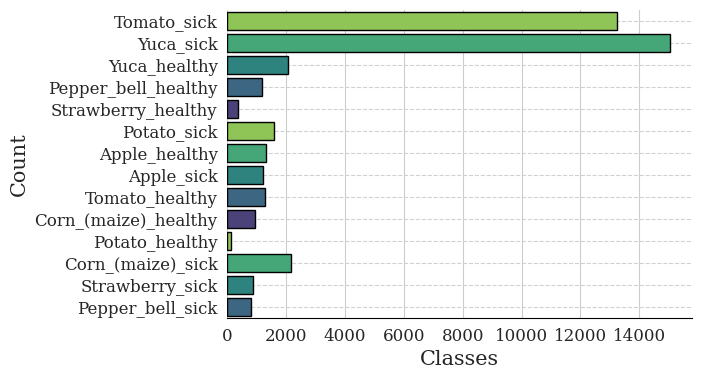

In [16]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(train.Planta_Estado, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.4. Conteo de imágenes por en el conjunto test por categoría

In [18]:
test.Planta_Estado.value_counts()

Planta_Estado
Yuca_sick               3764
Tomato_sick             3314
Corn_(maize)_sick        538
Yuca_healthy             516
Potato_sick              400
Apple_healthy            329
Tomato_healthy           318
Apple_sick               306
Pepper_bell_healthy      296
Corn_(maize)_healthy     232
Strawberry_sick          222
Pepper_bell_sick         199
Strawberry_healthy        91
Potato_healthy            30
Name: count, dtype: int64

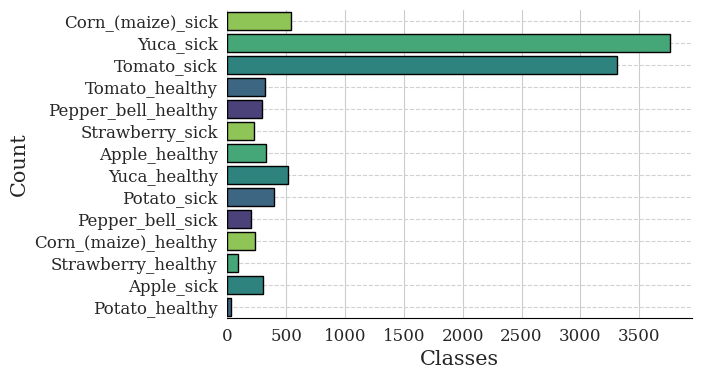

In [19]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(test.Planta_Estado, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.5. Muestra de Imagenes

In [21]:
# Cambiar el nombre de la columna
test = test.rename(columns={'Nombre del archivo': 'image_id'})
train = train.rename(columns={'Nombre del archivo': 'image_id'})

In [22]:
train.head()

,Carpeta,image_id,Planta,Condición,Saludable,Planta_Estado
28746,Tomato___Tomato_Yellow_Leaf_Curl_Virus,74b42d7f-309f-4473-b476-da57b293e601___YLCV_NR...,Tomato,Tomato_Yellow_Leaf_Curl_Virus,NO,Tomato_sick
51833,Casava,2523850258.jpg,Yuca,Cassava Bacterial Blight (CBB),NO,Yuca_sick
18975,Tomato___Bacterial_spot,ed94e669-2770-4452-9698-cfaea67e92d4___GCREC_B...,Tomato,Bacterial_spot,NO,Tomato_sick
55336,Casava,3164836946.jpg,Yuca,Cassava Brown Streak Disease (CBSD),NO,Yuca_sick
18629,Tomato___Bacterial_spot,b391ff43-597e-431d-b3eb-d852e5c9c754___GCREC_B...,Tomato,Bacterial_spot,NO,Tomato_sick


#### Plantas Healthy

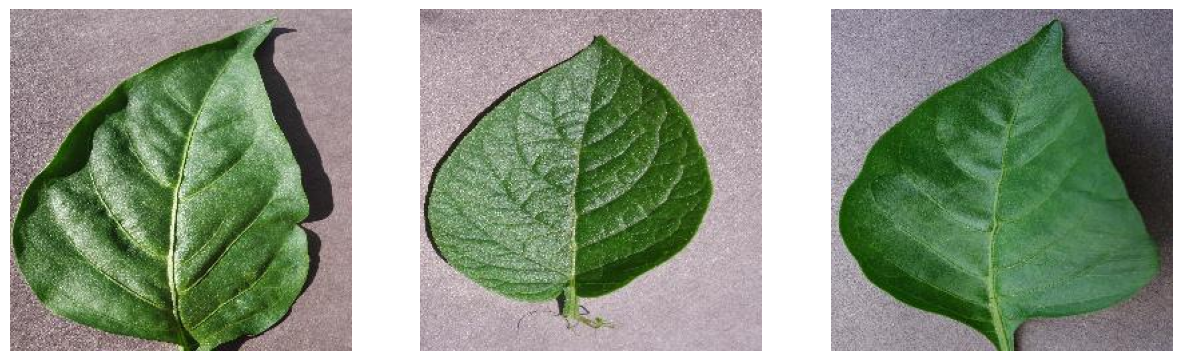

In [24]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "SI"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con alguna enfermedad

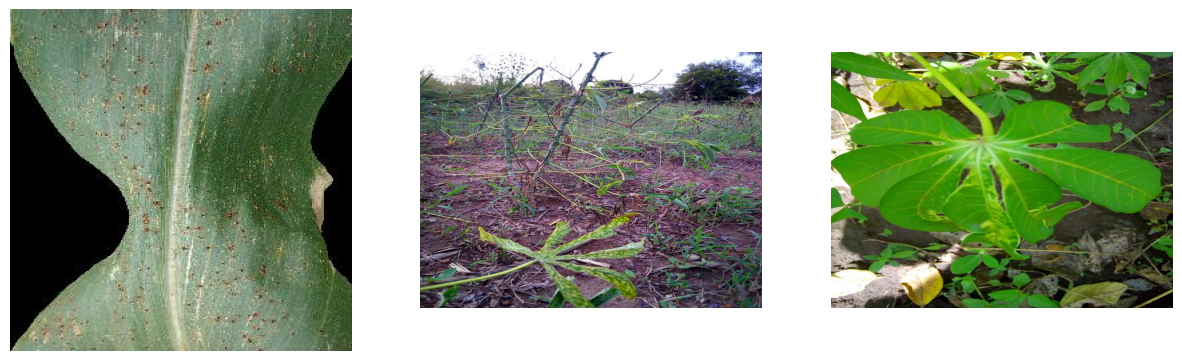

In [26]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "NO"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

Obtener el tamaño de las imágenes

In [28]:
image_path = os.path.join(image_folder, image_id)

# Definir la carpeta con las imágenes
image_folder = "Datos Finales"

# Función para obtener el tamaño de una imagen
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            return img.size  # Devuelve (ancho, alto)
    except Exception as e:
        print(f"Error con la imagen {image_path}: {e}")
        return None, None

In [29]:
# Obtener el tamaño de cada imagen y agregarlo al DataFrame
widths = []
heights = []

for img_name in train["image_id"]:  # Asegúrate de que la columna se llama "image_id"
    img_path = os.path.join(image_folder, img_name)
    width, height = get_image_size(img_path)
    widths.append(width)
    heights.append(height)

train["width"] = widths
train["height"] = heights

# Mostrar las primeras filas con los nuevos datos
print(train.head())

Error con la imagen Datos Finales/d46fe184-72f6-4b05-8376-b6e17edc5458___RS_NLB  4671.JPG: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/d46fe184-72f6-4b05-8376-b6e17edc5458___RS_NLB\xa0 4671.JPG'
Error con la imagen Datos Finales/.ipynb_checkpoints: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/.ipynb_checkpoints'
Error con la imagen Datos Finales/ed02da2f-8b98-49b1-a65d-ff7e47d61331___RS_NLB  4443.JPG: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/ed02da2f-8b98-49b1-a65d-ff7e47d61331___RS_NLB\xa0 4443.JPG'
Error con la imagen Datos Finales/76ffac09-0eab-4e97-9500-3d8237910165___RS_NLB  4627.JPG: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/76ffac09-0eab-4e97-9500-3d8237910165___RS

## 4. Preparación del Modelo

* Se implementará data augmentation para mejorar la generalización.
* Se evaluará el modelo con métricas como precisión y recall.

In [31]:
# Hiperparámetros principales
BATCH_SIZE = 10
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 15
TARGET_SIZE = 150

In [32]:
train.Planta_Estado = train.Planta_Estado.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Estado",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "Planta_Estado",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 33760 validated image filenames belonging to 14 classes.
Found 8440 validated image filenames belonging to 14 classes.


Imágen Aleatoria antes de Augmentation

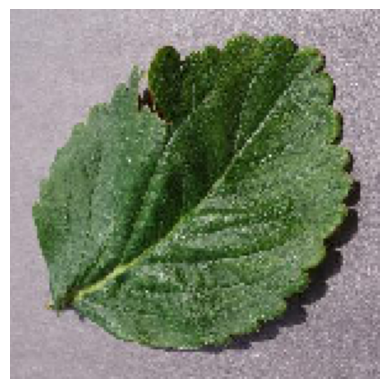

In [34]:
img_path = os.path.join("Datos Finales", train.image_id[20])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

In [35]:
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta_Estado",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

aug_images = [generator[0][0][0]/255 for i in range(10)]
fig, axes = plt.subplots(2, 5, figsize = (TARGET_SIZE, TARGET_SIZE))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

Found 1 validated image filenames belonging to 1 classes.


## 5. Construcción del Modelo

### 5.1. Clasificador

**Arquitectura del Modelo CNN**
El modelo es una red neuronal convolucional (**CNN**) diseñada para clasificar imágenes de plantas en distintas categorías. Su arquitectura incluye:

**1. Capas Convolucionales y de MaxPooling**
Cada capa convolucional extrae características de las imágenes, mientras que **MaxPooling** reduce la dimensionalidad, mejorando la eficiencia del modelo.

- **Capa 1:**  
  - `Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3))`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 2:**  
  - `Conv2D(64, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 3:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 4:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

**2. Capa de Aplanamiento**
Después de las capas convolucionales, se usa `Flatten()` para convertir la salida en un vector de una dimensión.

**3. Capas Densas y Regularización**
- Una capa densa con **512 neuronas** y función de activación ReLU.
- Se usa **Dropout (0.5)** para reducir el sobreajuste.
  
**4. Capa de Salida**
- `Dense(14, activation='softmax')`  
- La activación **softmax** se usa porque se trata de un problema de clasificación multiclase (14 categorías).

In [38]:
# Arquitectura del modelo CNN
model = models.Sequential()

# Capa 1: Convolucional y MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 2: Convolucional y MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 3: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 4: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Aplanamiento de la capa convolucional
model.add(layers.Flatten())

# Clasificador
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout para evitar el overfitting

# Capa de salida
model.add(layers.Dense(num_categorias, activation='softmax'))  

### 5.2. Compilación del modelo

In [40]:
model.compile(
    loss='categorical_crossentropy',  # Cambiado a 'categorical_crossentropy' para múltiples clases
    optimizer='adam',
    metrics=['accuracy']
)

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,461,198 (13.20 MB)

 Trainable params: 3,460,494 (13.20 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Ejecución del modelo

* Se entrenará el modelo utilizando Adam como optimizador y EarlyStopping para prevenir sobreajuste.
* Se evaluará el desempeño sobre el conjunto de prueba.

In [43]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [44]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/15
3376/3376 - 681s - 202ms/step - accuracy: 0.6908 - loss: 1.2908 - val_accuracy: 0.7019 - val_loss: 0.9455 - learning_rate: 0.0010
Epoch 2/15
3376/3376 - 623s - 185ms/step - accuracy: 0.7594 - loss: 0.8007 - val_accuracy: 0.7506 - val_loss: 1.0373 - learning_rate: 0.0010
Epoch 3/15
3376/3376 - 544s - 161ms/step - accuracy: 0.7906 - loss: 0.6863 - val_accuracy: 0.8006 - val_loss: 0.7109 - learning_rate: 0.0010
Epoch 4/15
3376/3376 - 546s - 162ms/step - accuracy: 0.8206 - loss: 0.5720 - val_accuracy: 0.7713 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 5/15
3376/3376 - 545s - 161ms/step - accuracy: 0.8460 - loss: 0.4877 - val_accuracy: 0.8983 - val_loss: 0.2991 - learning_rate: 0.0010
Epoch 6/15
3376/3376 - 544s - 161ms/step - accuracy: 0.8637 - loss: 0.4303 - val_accuracy: 0.8654 - val_loss: 0.4212 - learning_rate: 0.0010
Epoch 7/15
3376/3376 - 541s - 160ms/step - accuracy: 0.8778 - loss: 0.3818 - val_accuracy: 0.8944 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 8/15
33

### 6.1. Resultados del Modelo

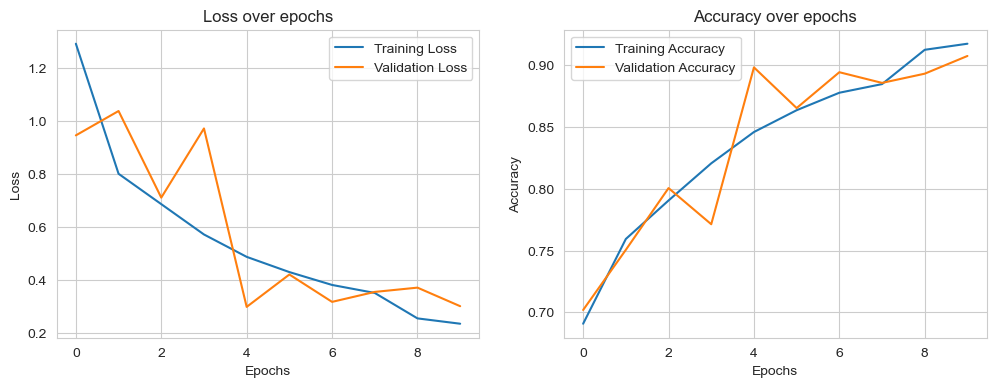

In [46]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [50]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8,9,10]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        1.290817         0.945493           0.690758   
1      2        0.800734         1.037264           0.759390   
2      3        0.686341         0.710865           0.790551   
3      4        0.572009         0.971545           0.820646   
4      5        0.487689         0.299123           0.846001   
5      6        0.430300         0.421171           0.863655   
6      7        0.381816         0.318054           0.877814   
7      8        0.351692         0.355566           0.884804   
8      9        0.255814         0.371690           0.912589   
9     10        0.235715         0.301781           0.917506   

   Validation  Accuracy  
0              0.701896  
1              0.750592  
2              0.800592  
3              0.771327  
4              0.898341  
5              0.865403  
6              0.894431  
7              0.885782  
8              0.893246  
9              0.907583  


In [52]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-03-26 03:23:23.941028
Duración: 6:17:04.777620
